## Access Animal Satellite Relay Tagging Ctd Realtime Qc (Parquet)
This Jupyter notebook demonstrates how to access and plot animal_satellite_relay_tagging_ctd_realtime_qc data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/b2548767-514f-4a31-b65e-36bb894382d5).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/animal_satellite_relay_tagging_ctd_realtime_qc.ipynb).


In [1]:
dataset_name = "animal_satellite_relay_tagging_ctd_realtime_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 201 packages in 512ms
Checked 201 packages in 2ms


✅ Local version 0.3.18 is up to date (remote: 0.3.18)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4590: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn(bucket_name="imos-data-lab-optimised")
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 5.18 ms, sys: 1.67 ms, total: 6.85 ms
Wall time: 6.28 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 1.38 ms, sys: 750 µs, total: 2.13 ms
Wall time: 1.28 ms


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


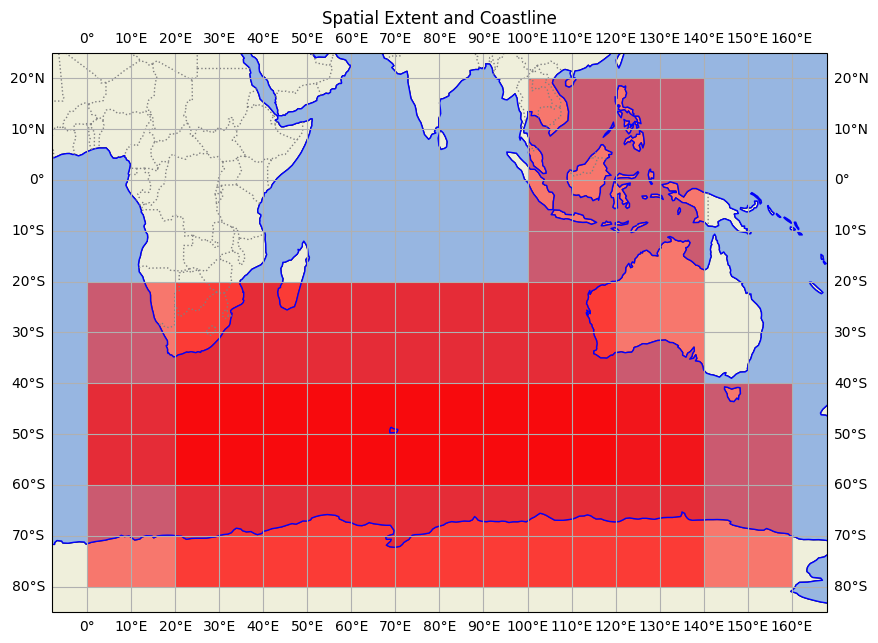

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 271 ms, sys: 56.1 ms, total: 328 ms
Wall time: 742 ms


(Timestamp('2025-12-31 16:30:00'), Timestamp('2026-05-28 18:35:00'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-06-01 14:17:26,043 - aodn.GetAodn - INFO - Retrieving metadata for imos-data-lab-optimised/animal_satellite_relay_tagging_ctd_realtime_qc.parquet


{'ref': {'type': 'string'},
 'ptt': {'type': 'int32'},
 'end_date': {'type': 'timestamp[ns]'},
 'max_dbar': {'type': 'double'},
 'num': {'type': 'int32'},
 'n_temp': {'type': 'int32'},
 'n_cond': {'type': 'double'},
 'n_sal': {'type': 'int32'},
 'temp_dbar': {'type': 'double'},
 'temp_vals': {'type': 'double'},
 'cond_dbar': {'type': 'double'},
 'cond_vals': {'type': 'double'},
 'sal_dbar': {'type': 'double'},
 'sal_vals': {'type': 'double'},
 'n_fluoro': {'type': 'double'},
 'fluoro_dbar': {'type': 'double'},
 'fluoro_vals': {'type': 'double'},
 'n_oxy': {'type': 'double'},
 'oxy_dbar': {'type': 'double'},
 'oxy_vals': {'type': 'double'},
 'qc_profile': {'type': 'int32'},
 'qc_temp': {'type': 'double'},
 'qc_sal': {'type': 'double'},
 'sal_corrected_vals': {'type': 'double'},
 'created': {'type': 'string'},
 'modified': {'type': 'string'},
 'n_photo': {'type': 'double'},
 'photo_dbar': {'type': 'double'},
 'photo_vals': {'type': 'double'},
 'lat': {'type': 'double'},
 'lon': {'type': 

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
df = aodn_dataset.get_data(

                           )

df.info()

2026-06-01 14:17:26,888 - aodn.GetAodn - INFO - Retrieving metadata for imos-data-lab-optimised/animal_satellite_relay_tagging_ctd_realtime_qc.parquet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263288 entries, 0 to 263287
Data columns (total 41 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ref                 263288 non-null  object        
 1   ptt                 263288 non-null  int32         
 2   end_date            263288 non-null  datetime64[ns]
 3   max_dbar            263288 non-null  float64       
 4   num                 263288 non-null  int32         
 5   n_temp              227481 non-null  float64       
 6   n_cond              0 non-null       float64       
 7   n_sal               227481 non-null  float64       
 8   temp_dbar           227481 non-null  float64       
 9   temp_vals           227481 non-null  float64       
 10  cond_dbar           0 non-null       float64       
 11  cond_vals           0 non-null       float64       
 12  sal_dbar            227481 non-null  float64       
 13  sal_vals            227481 no

In [11]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


#df.aodn.download_as_csv()

## Create a TIME and scalar/number filter

This cell filters the dataset by time range and a scalar value (from a Parquet partition) using the `scalar_filter` argument.  
This leverages Parquet partitioning to apply efficient, server-side filtering, which significantly speeds up data loading.

In [14]:
%%time
df = aodn_dataset.get_data(date_start='2026-04-01', 
                           date_end='2026-04-02',
)
df.info()

2026-06-01 14:19:56,644 - aodn.GetAodn - INFO - Retrieving metadata for imos-data-lab-optimised/animal_satellite_relay_tagging_ctd_realtime_qc.parquet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ref                 1781 non-null   object        
 1   ptt                 1781 non-null   int32         
 2   end_date            1781 non-null   datetime64[ns]
 3   max_dbar            1781 non-null   float64       
 4   num                 1781 non-null   int32         
 5   n_temp              1557 non-null   float64       
 6   n_cond              0 non-null      float64       
 7   n_sal               1557 non-null   float64       
 8   temp_dbar           1557 non-null   float64       
 9   temp_vals           1557 non-null   float64       
 10  cond_dbar           0 non-null      float64       
 11  cond_vals           0 non-null      float64       
 12  sal_dbar            1557 non-null   float64       
 13  sal_vals            1557 non-null   float64     

In [17]:
df["ref"].unique()

array(['ct189-593-25', 'ct189-580-25', 'ct190-F995-24', 'ct190-978-24',
       'ct189-576-25', 'ct189-586-25', 'ct190-897-24',
       'ct190-266-BAT2-20', 'ct190-997-24', 'ct190-F988-24',
       'ct190-976-24', 'ct190-896-24', 'ct189-587-25', 'ct189-589-25',
       'ct189-591-25', 'ct189-596-25', 'ct190-F999-24', 'ct189-594-25',
       'ct189-588-25', 'ct189-584-25', 'ct189-585-25', 'ct190-000-24',
       'ct189-581-25', 'ct189-595-25'], dtype=object)

In [32]:
df_subset = df[
    (df["ref"] == "ct189-596-25") & (df["end_date"] == "2026-04-01 04:00:00")
].sort_values(by="temp_dbar")

In [33]:
df_subset

,ref,ptt,end_date,max_dbar,num,n_temp,n_cond,n_sal,temp_dbar,temp_vals,...,ssm_lon,ssm_lat,ssm_x,ssm_y,ssm_x_se,ssm_y_se,cid,filename,timestamp,polygon
294,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,4.0,-1.728,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
288,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,8.0,-1.729,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
302,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,10.0,-1.729,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
301,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,20.0,-1.729,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
300,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,30.0,-1.719,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
299,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,38.0,-1.686,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
298,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,42.0,-1.659,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
297,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,46.0,-1.598,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
303,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,50.0,-1.589,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...
296,ct189-596-25,35416,2026-04-01 04:00:00,218.0,0,16.0,NaN,16.0,62.0,-1.586,...,93.681901,-65.20758,-300.969562,2718.280621,2.243218,2.249265,ct189,IMOS_ATF-SATTAG_Location-QC_ctd_ct189_nrt.csv,1767225600,010300000001000000050000000000000000004E400000...


<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1178890/206553164.py:21: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel("Temperature ($^\circ$C)")
/tmp/ipykernel_1178890/206553164.py:40: SyntaxWarning: invalid escape sequence '\c'
  f"Temp range: {df_subset['temp_vals'].min()}$^\circ$C to {df_subset['temp_vals'].max()}$^\circ$C"
/tmp/ipykernel_1178890/206553164.py:40: SyntaxWarning: invalid escape sequence '\c'
  f"Temp range: {df_subset['temp_vals'].min()}$^\circ$C to {df_subset['temp_vals'].max()}$^\circ$C"


--- Profile Plot Debug Summary ---
Data points plotted: 16
Depth range: 4.0 to 218.0 dbar
Temp range: -1.729$^\circ$C to -1.586$^\circ$C
Missing temperature values: 0
-----------------------------------


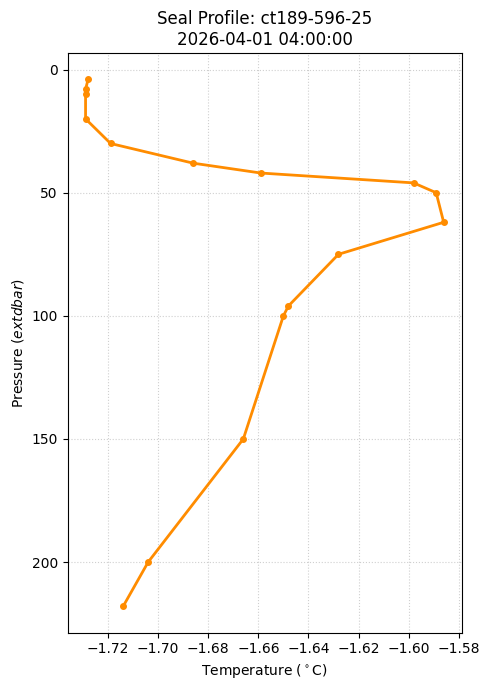

In [34]:
import matplotlib.pyplot as plt

# Initialize a clean plot layout
fig, ax = plt.subplots(figsize=(5, 7))

# Plot Temperature against Pressure (dbar acts as depth)
ax.plot(
    df_subset["temp_vals"],
    df_subset["temp_dbar"],
    marker="o",
    linestyle="-",
    color="darkorange",
    linewidth=2,
    markersize=4,
)

# Invert the y-axis so greater depth/pressure is at the bottom
ax.invert_yaxis()

# Labeling with proper scientific notation
ax.set_xlabel("Temperature ($^\circ$C)")
ax.set_ylabel("Pressure ($\text{dbar}$)")
ax.set_title(
    f"Seal Profile: {df_subset['ref'].iloc[0]}\n{df_subset['end_date'].iloc[0]}"
)
ax.grid(True, linestyle=":", alpha=0.6)

# Save the plot
plt.tight_layout()
plt.savefig("seal_temperature_profile.png", dpi=300)


# --- Quick Debug Block ---
print("--- Profile Plot Debug Summary ---")
print(f"Data points plotted: {len(df_subset)}")
print(
    f"Depth range: {df_subset['temp_dbar'].min()} to {df_subset['temp_dbar'].max()} dbar"
)
print(
    f"Temp range: {df_subset['temp_vals'].min()}$^\circ$C to {df_subset['temp_vals'].max()}$^\circ$C"
)
print("Missing temperature values:", df_subset["temp_vals"].isna().sum())
print("-----------------------------------")

In [41]:
df = aodn_dataset.get_data()

2026-06-01 14:39:09,528 - aodn.GetAodn - INFO - Retrieving metadata for imos-data-lab-optimised/animal_satellite_relay_tagging_ctd_realtime_qc.parquet


/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/pyproj/transformer.py:816: UserWarning: Warning: converting a masked element to nan.
  return self._transformer._transform_point(
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/pyproj/transformer.py:816: UserWarning: Warning: converting a masked element to nan.
  return self._transformer._transform_point(
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/pyproj/transfor

--- Land Contour Map Debug ---
Map Extent Bounds: Lon(32.40 to 159.20), Lat(-70.87 to -8.23)
Total rows rendered: 263288
------------------------------


/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/pyproj/transformer.py:816: UserWarning: Warning: converting a masked element to nan.
  return self._transformer._transform_point(
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/pyproj/transformer.py:816: UserWarning: Warning: converting a masked element to nan.
  return self._transformer._transform_point(
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/pyproj/transformer.py:816: UserWarning: Warning: converting a masked element to nan.
  return self._transformer._transform_point(
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/pyproj/transformer.py:816: UserWarning: Warning: converting a masked element to nan.
  return self._transformer._transform_point(
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/pyproj/transformer.py:816: UserWarning: Warning: converting a mas

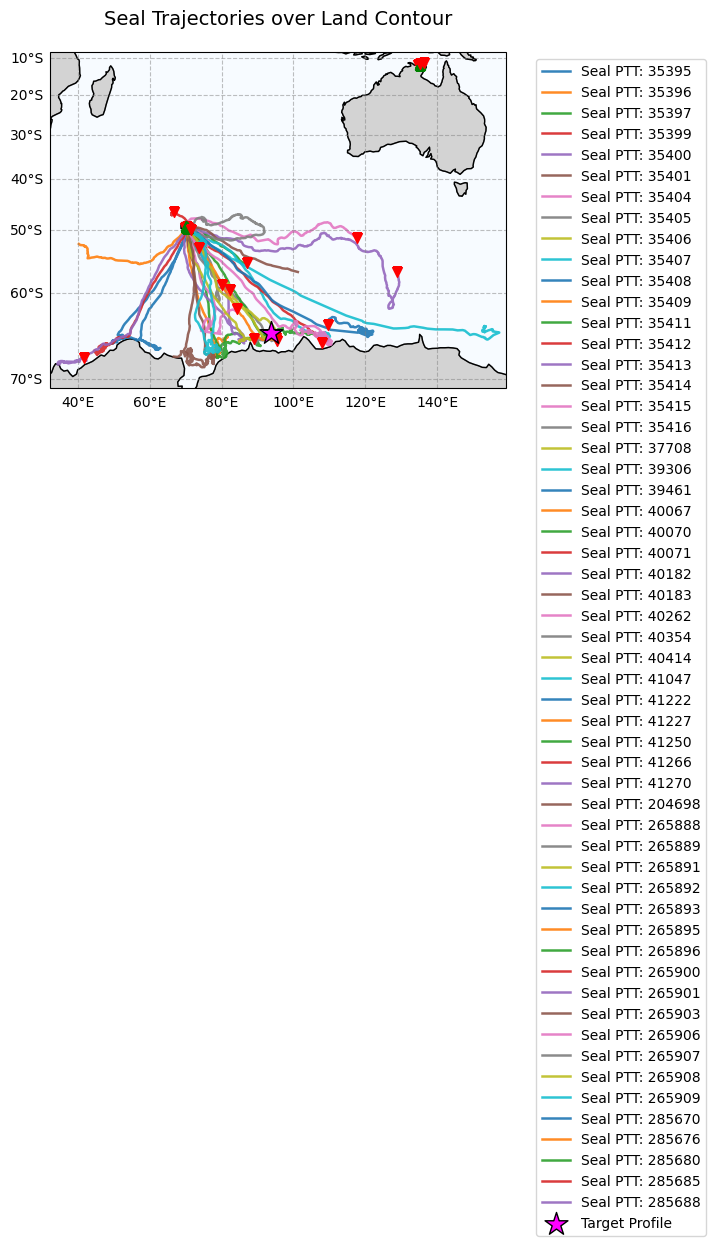

In [42]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# 1. Setup the figure and map projection
# Using Mercator projection here; for polar/Antarctic tracks, ccrs.SouthPolarStereo() is also excellent.
plt.figure(figsize=(12, 9))
projection = ccrs.Mercator()
ax = plt.axes(projection=projection)

# 2. Add Land Contours and Ocean features
# '110m' is low resolution (fast), use '50m' or '10m' for highly detailed coastlines
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="dimgray")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="black")

# 3. Sort the entire dataframe chronologically
df_sorted = df.sort_values(by="end_date")

# 4. Group by the seal ID (ptt) and plot each track
for ptt_id, seal_df in df_sorted.groupby("ptt"):

    # IMPORTANT: When using Cartopy, you must specify the coordinate system of your data (usually PlateCarree for standard Lat/Lon)
    (line,) = ax.plot(
        seal_df["ssm_lon"],
        seal_df["ssm_lat"],
        linestyle="-",
        linewidth=1.8,
        alpha=0.9,
        label=f"Seal PTT: {ptt_id}",
        transform=ccrs.PlateCarree(),  # Tells cartopy these are standard lat/lon degrees
    )

    # Add start (green) and end (red) markers
    if len(seal_df) > 0:
        ax.scatter(
            seal_df["ssm_lon"].iloc[0],
            seal_df["ssm_lat"].iloc[0],
            color="green",
            marker="^",
            s=50,
            zorder=3,
            transform=ccrs.PlateCarree(),
        )
        ax.scatter(
            seal_df["ssm_lon"].iloc[-1],
            seal_df["ssm_lat"].iloc[-1],
            color="red",
            marker="v",
            s=50,
            zorder=3,
            transform=ccrs.PlateCarree(),
        )

# 5. Highlight your target profile subset if it exists
if "df_subset" in locals() and not df_subset.empty:
    ax.scatter(
        df_subset["ssm_lon"].iloc[0],
        df_subset["ssm_lat"].iloc[0],
        color="magenta",
        marker="*",
        s=300,
        edgecolor="black",
        label="Target Profile",
        zorder=5,
        transform=ccrs.PlateCarree(),
    )

# 6. Dynamically zoom the map view slightly wider than the seal data bounds
pad = 2.0  # degrees of padding around the track bounds
lon_min, lon_max = df["ssm_lon"].min() - pad, df["ssm_lon"].max() + pad
lat_min, lat_max = df["ssm_lat"].min() - pad, df["ssm_lat"].max() + pad
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add gridlines with map coordinates labeled
grid = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5, color="gray")
grid.top_labels = False
grid.right_labels = False

plt.title("Seal Trajectories over Land Contour", fontsize=14, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("seal_trajectories_with_land.png", dpi=300)


# --- Quick Debug Block ---
print("--- Land Contour Map Debug ---")
print(f"Map Extent Bounds: Lon({lon_min:.2f} to {lon_max:.2f}), Lat({lat_min:.2f} to {lat_max:.2f})")
print(f"Total rows rendered: {len(df_sorted)}")
print("------------------------------")

In [46]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import pandas as pd
# This line allows you to render HTML5 video directly inside a Jupyter notebook cell
from IPython.display import HTML

# 1. Prepare and sort data
df["date_only"] = df["end_date"].dt.date
df_sorted = df.sort_values(by="end_date")
unique_days = sorted(df["date_only"].unique())
ptt_ids = df_sorted["ptt"].unique()

# Pre-allocate dictionary structures to hold coordinate histories
track_history = {day: {ptt: ([], []) for ptt in ptt_ids} for day in unique_days}
accumulated_data = {ptt: ([], []) for ptt in ptt_ids}
day_groups = df_sorted.groupby("date_only")

for day in unique_days:
    if day in day_groups.groups:
        day_df = day_groups.get_group(day)
        for ptt_id, seal_df in day_df.groupby("ptt"):
            lon_list, lat_list = accumulated_data[ptt_id]
            lon_list.extend(seal_df["ssm_lon"].tolist())
            lat_list.extend(seal_df["ssm_lat"].tolist())

    for ptt_id in ptt_ids:
        track_history[day][ptt_id] = (
            list(accumulated_data[ptt_id][0]),
            list(accumulated_data[ptt_id][1]),
        )

# 2. Setup the Map Canvas
fig = plt.figure(figsize=(12, 9))
projection = ccrs.Mercator()
ax = plt.axes(projection=projection)

ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="dimgray")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="black")

pad = 2.0
ax.set_extent(
    [
        df["ssm_lon"].min() - pad,
        df["ssm_lon"].max() + pad,
        df["ssm_lat"].min() - pad,
        df["ssm_lat"].max() + pad,
    ],
    crs=ccrs.PlateCarree(),
)

ax.gridlines(draw_labels=True, linestyle="--", alpha=0.3, color="gray")

# Initialize tracking lines (Removed the 'label=' parameter since we don't need a legend)
lines = {}
for ptt_id in ptt_ids:
    (line,) = ax.plot(
        [], [], linestyle="-", linewidth=1.5, alpha=0.7, transform=ccrs.PlateCarree()
    )
    lines[ptt_id] = line

title_text = ax.set_title("Seal Tracking Evolution", fontsize=14, pad=20)
plt.tight_layout()


# 3. Optimized Update Function
def update(frame):
    current_day = unique_days[frame]

    for ptt_id, line in lines.items():
        lons, lats = track_history[current_day][ptt_id]
        line.set_data(lons, lats)

    title_text.set_text(
        f"Seal Trajectories Evolution\nDate: {current_day.strftime('%Y-%m-%d')}"
    )
    return list(lines.values()) + [title_text]


# 4. Create the animation object
ani = animation.FuncAnimation(
    fig, update, frames=len(unique_days), interval=150, blit=False
)

# Crucial step: Prevent matplotlib from showing a duplicate static plot canvas below
plt.close()

# 5. Render directly in the Notebook
# This converts the animation object into an HTML5 stream with Play/Pause controls!
HTML(ani.to_html5_video())

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/lbesnard/github_repo/aodn_cloud_optimised/